In [1]:
# Imports.
import numpy as np;
import xarray as xr;
import matplotlib.pyplot as plt;
import h5_reader_xr as reader;
import gysela_utilities as gys_utils;
import phi2D_utilities as utils;
import phi2D_analytical as analytical;
from scipy.signal import find_peaks;

# Styling.
plt.style.use("ggplot");

In [2]:
# Test inputs - delete when done!
perturbed_case_directory_path = "/zhisongqu_data/seth/GYSELA/raw/vestigial/DN_GG2019_QSCAN_1.5";
quiescent_case_directory_path = None;
perturbed_case_data_arrays = reader.fetch_phi2D_data(perturbed_case_directory_path, parallelise = True);
quiescent_case_data_arrays = reader.fetch_phi2D_data(quiescent_case_directory_path, parallelise = True) if quiescent_case_directory_path is not None else None;
dt_diag = reader.fetch_dt_diag(perturbed_case_directory_path);
jacobian_dictionary = reader.fetch_jacobian(perturbed_case_directory_path);

Found 1501 files in the directory. Loading with 16 workers...


[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    1.0s
[Parallel(n_jobs=16)]: Done 464 tasks      | elapsed:    1.8s
[Parallel(n_jobs=16)]: Done 1501 out of 1501 | elapsed:    3.4s finished


Finished compiling data from all files in the directory.


In [28]:
def plot_gam_damping(phi2D_list, dt_diag, jacobian_dictionary, GAM_frequency, effective_radius = None, quiescent_phi2D_list = None, skip_peaks = 2):
	# We start with Phi_00.
	fs_avg_time_series = utils.generate_poloidally_averaged_time_series(phi2D_list, jacobian_dictionary);

	if quiescent_phi2D_list is not None:

		quiescent_radial_time_series = utils.generate_poloidally_averaged_time_series(quiescent_phi2D_list, jacobian_dictionary);
		fs_avg_time_series = fs_avg_time_series - quiescent_radial_time_series;

	fs_avg_time_series_at_r = gys_utils.slice_at_effective_radius(fs_avg_time_series, effective_radius);
	radially_averaged_time_series = gys_utils.radial_average_1D(fs_avg_time_series, jacobian_dictionary);

	# The values to be plotted.
	decay_signal_xr = fs_avg_time_series_at_r - radially_averaged_time_series;
	decay_signal = decay_signal_xr.values;
	time_range = np.arange(len(decay_signal)) * dt_diag;
	
	# Peak isolation.
	minimum_distance = 0.5 * (1 / GAM_frequency) * (1 / dt_diag);
	print(f"Setting minimum distance for interpolation to be {minimum_distance: .3} in code units.");
	peak_indices, _ = find_peaks(decay_signal, distance = minimum_distance);
	peak_times = time_range[peak_indices][skip_peaks:];
	peak_values = decay_signal[peak_indices][skip_peaks:];
	print(f"Found {len(peak_indices)} peaks.");

	# Fitting.
	log_peaks = np.log(peak_values);
	damping_rate, log_amplitude = np.polyfit(peak_times, log_peaks, 1);
	fitted_line = np.exp(log_amplitude) * np.exp(damping_rate * time_range);
	print("Plotting...");

	# Figure plotting logic.
	_, ax = plt.subplots(figsize = (10, 6));
	ax.semilogy(time_range, decay_signal, label = "Signal", color = "red", linestyle = "solid");
	ax.plot(time_range, fitted_line, label = "Fitted Exponential Decay", color = "blue", linestyle = "--");
	ax.scatter(peak_times, np.abs(peak_values), label = "Peaks", color = "black", marker = "o");
	ax.set_title(fr"$\gamma \Omega_i^{{-1}} = {damping_rate: .3e}$", fontsize = 16, pad = 15);
	ax.set_xlabel(r"time $\times \Omega_i$", fontsize = 16, labelpad = 10);
	ax.set_ylabel(r"$\phi_{00} - \langle \phi_{00} \rangle_{r}$", fontsize = 16, labelpad = 10);
	ax.grid(True, which = "major", linestyle = ":", color = "gray", linewidth = 1);
	ax.tick_params(axis = "both", which = "major", labelsize = 14, direction = "in");
	plt.legend(frameon = True, loc = "lower right");
	plt.tight_layout();
	plt.show();

Setting minimum distance for interpolation to be  19.8 in code units.
Found 20 peaks.
Plotting...


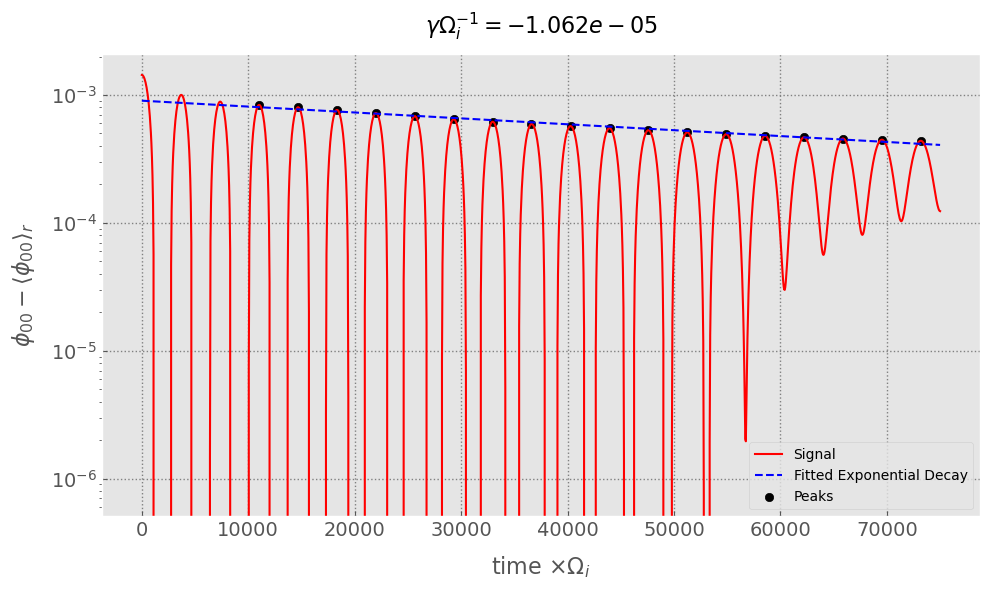

In [ ]:
effective_radius = 0.7;
GAM_frequency = utils.extract_gam_frequency(perturbed_case_data_arrays, dt_diag, jacobian_dictionary, effective_radius);
plot_gam_damping(perturbed_case_data_arrays, dt_diag, jacobian_dictionary, GAM_frequency, effective_radius, quiescent_phi2D_list = quiescent_case_data_arrays, skip_peaks = 0);